In [ ]:
from pathlib import Path
import os
import stat
import json
from tqdm import tqdm

import numpy as np
import pandas as pd
import arviz as az
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt

/Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
os.environ['CC'] = 'clang'
os.environ['CXX'] = 'clang++'

In [3]:
df = pd.read_csv('../data/fire_db.csv')

In [4]:
df.columns

Index(['province', 'fire_cause', 'fire_type', 'response_type',
       'protection_zone', 'fn_indicator', 'dist_to_fn_km', 'n_fn_20km',
       'any_evacuation', 'log_fire_size_ha'],
      dtype='str')

## Super Simple Model

In [5]:
df0 = df[['any_evacuation', 'log_fire_size_ha', 'fn_indicator']].dropna().copy()

stan_data_0 = {
    'N': len(df0),
    'y': df0['any_evacuation'].astype(int).tolist(),
    'log_fire_size': df0['log_fire_size_ha'].astype(float).tolist(),
    'fn_indicator': df0['fn_indicator'].astype(int).tolist(),
}

In [6]:
# Remove stale compiler overrides from this notebook session

stan_file = Path('../stan/minimal.stan').resolve()
exe_file = stan_file.with_suffix('')   # ../stan/minimal
outdir = (Path.cwd() / 'stan_output' / 'minimal').resolve()
outdir.mkdir(parents=True, exist_ok=True)

In [7]:
# First time: compile if needed
model = CmdStanModel(stan_file=str(stan_file))

# Make sure the executable bit is set
mode = os.stat(model.exe_file).st_mode
os.chmod(model.exe_file, mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)

print('model exe:', model.exe_file)

model exe: /Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/stan/minimal


In [8]:
fit = model.sample(
    data=stan_data_0,
    chains=1,
    parallel_chains=4,
    iter_warmup=500,
    iter_sampling=500,
    seed=42,
    show_console=False,
    # output_dir=str(outdir),
)

15:34:29 - cmdstanpy - INFO - Requested 4 parallel_chains but only 1 required, will run all chains in parallel.
15:34:30 - cmdstanpy - INFO - CmdStan start processing
chain 1: 100%|██████████| 1000/1000 [00:19<00:00, 52.51it/s, (Sampling completed)]


15:34:50 - cmdstanpy - INFO - CmdStan done processing.


In [9]:
summary = fit.summary()
print(summary.loc[['alpha', 'beta_log_fire_size', 'beta_fn']])

                        Mean      MCSE    StdDev       MAD        5%  \
alpha              -3.436590  0.002303  0.047642  0.049525 -3.514370   
beta_log_fire_size  0.377786  0.002060  0.038870  0.040267  0.314502   
beta_fn             1.445010  0.012563  0.205008  0.210233  1.136520   

                         50%       95%  ESS_bulk  ESS_tail  ESS_bulk/s  \
alpha              -3.436530 -3.361300   443.244   395.170     32.1891   
beta_log_fire_size  0.379618  0.438561   362.483   186.335     26.3241   
beta_fn             1.448350  1.785670   260.200   313.085     18.8962   

                      R_hat  
alpha               1.00032  
beta_log_fire_size  0.99835  
beta_fn             1.00559  


In [ ]:


idata = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive='y_rep',
    log_likelihood='log_lik',
)

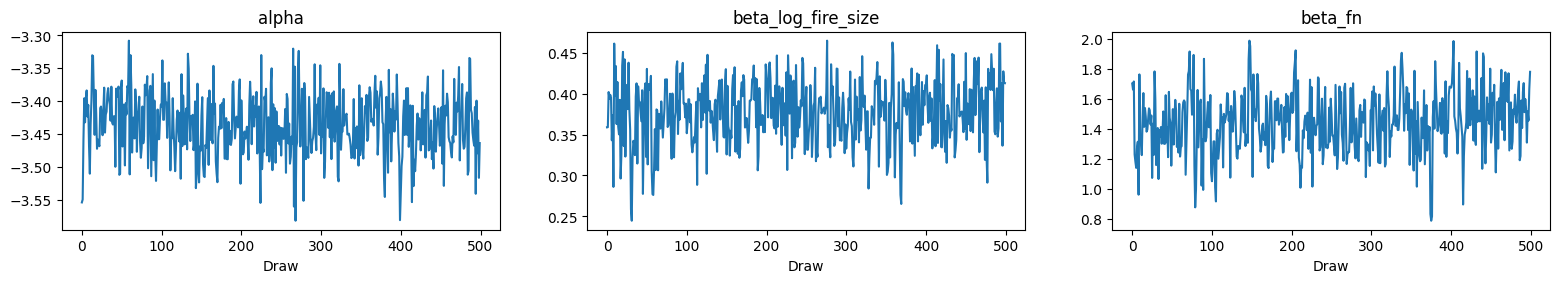

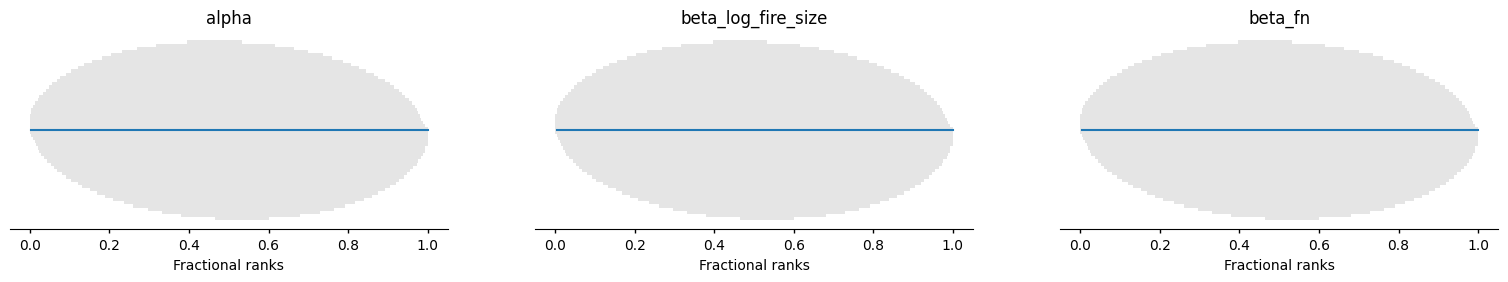

In [11]:
az.plot_trace(
    idata,
    var_names=['alpha', 'beta_log_fire_size', 'beta_fn'],
)
plt.show()

az.plot_rank(
    idata,
    var_names=['alpha', 'beta_log_fire_size', 'beta_fn'],
)
plt.show()

In [12]:
import numpy as np

y_rep = idata['posterior_predictive']['y_rep'].stack(sample=('chain', 'draw')).values
y_obs = df['any_evacuation'].to_numpy()

if y_rep.shape == (500, len(y_obs)):
    y_rep = y_rep.T
elif y_rep.shape != (len(y_obs), 500):
    print('Unexpected shape:', y_rep.shape)

rep_totals = y_rep.sum(axis=0)
obs_total = y_obs.sum()

lo, hi = np.quantile(rep_totals, [0.025, 0.975])
p_upper = np.mean(rep_totals >= obs_total)
p_lower = np.mean(rep_totals <= obs_total)
p_two = min(1.0, 2 * min(p_upper, p_lower))

print('Observed total:', obs_total)
print('Replicated 95% interval:', (lo, hi))
print('Upper-tail PPC p-value:', p_upper)
print('Two-sided PPC p-value:', p_two)

Observed total: 531
Replicated 95% interval: (np.float64(473.475), np.float64(592.525))
Upper-tail PPC p-value: 0.476
Two-sided PPC p-value: 0.952


## Run and compare the three Stan models
The cells below prepare data for each model, compile and sample the three Stan files we added (`logistic_province.stan`, `logistic_full.stan`, `logistic_response.stan`), then convert to ArviZ and compare diagnostics (ESS, Rhat) and information criteria (LOO, WAIC).

In [13]:
# Unset environment variables which cause compilation issues
import os
os.environ.pop('CXX', None)
os.environ.pop('CC', None)

'clang'

In [14]:
# Paths to the three Stan files and output directories
stan_dir = Path('../stan').resolve()
models = {
    'minimal': { 'file': stan_dir / 'minimal.stan', 'outdir': Path.cwd() / 'stan_output' / 'minimal' },
    'province': { 'file': stan_dir / 'logistic_province.stan', 'outdir': Path.cwd() / 'stan_output' / 'province' },
    'full': { 'file': stan_dir / 'logistic_full.stan', 'outdir': Path.cwd() / 'stan_output' / 'full' },
    'response': { 'file': stan_dir / 'logistic_response.stan', 'outdir': Path.cwd() / 'stan_output' / 'response' },
}
for m in models.values():
    m['outdir'].mkdir(parents=True, exist_ok=True)

# Helper to compile if needed
def compile_model(stan_path):
    print('Compiling', stan_path.name)
    mdl = CmdStanModel(stan_file=str(stan_path))
    mode = os.stat(mdl.exe_file).st_mode
    os.chmod(mdl.exe_file, mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)
    return mdl

In [20]:
# Prepare stan_data for each model from `df`
# Province model: need 1-based province index
df0 = df[['any_evacuation', 'log_fire_size_ha', 'fn_indicator']].dropna().copy()

stan_data_0 = {
    'N': len(df0),
    'y': df0['any_evacuation'].astype(int).tolist(),
    'log_fire_size': df0['log_fire_size_ha'].astype(float).tolist(),
    'fn_indicator': df0['fn_indicator'].astype(int).tolist(),
}
df_proc = df.dropna(subset=['any_evacuation','log_fire_size_ha','fn_indicator']).copy()
prov_cat = pd.Categorical(df_proc['province'])
df_proc['prov_idx'] = prov_cat.codes + 1
stan_data_province = {
    'N': len(df_proc),
    'P': len(prov_cat.categories),
    'province': df_proc['prov_idx'].astype(int).tolist(),
    'y': df_proc['any_evacuation'].astype(int).tolist(),
    'log_fire_size': df_proc['log_fire_size_ha'].astype(float).tolist(),
    'fn_indicator': df_proc['fn_indicator'].astype(int).tolist(),
}
# Full model: encode categorical features as 1..K indices
df_full = df.dropna(subset=['any_evacuation','log_fire_size_ha','fn_indicator','dist_to_fn_km','n_fn_20km','fire_cause','fire_type','protection_zone']).copy()
cause_cat = pd.Categorical(df_full['fire_cause'])
type_cat = pd.Categorical(df_full['fire_type'])
prot_cat = pd.Categorical(df_full['protection_zone'])
stan_data_full = {
    'N': len(df_full),
    'y': df_full['any_evacuation'].astype(int).tolist(),
    'log_fire_size': df_full['log_fire_size_ha'].astype(float).tolist(),
    'dist_to_fn_km': df_full['dist_to_fn_km'].astype(float).tolist(),
    'n_fn_20km': df_full['n_fn_20km'].astype(int).tolist(),
    'fn_indicator': df_full['fn_indicator'].astype(int).tolist(),
    'K_cause': len(cause_cat.categories),
    'fire_cause': (cause_cat.codes + 1).tolist(),
    'K_type': len(type_cat.categories),
    'fire_type': (type_cat.codes + 1).tolist(),
    'K_prot': len(prot_cat.categories),
    'protection_zone': (prot_cat.codes + 1).tolist(),
}
# Response model: needs response_type plus province and other predictors
df_resp = df.dropna(subset=['any_evacuation','log_fire_size_ha','fn_indicator','dist_to_fn_km','n_fn_20km','fire_cause','fire_type','protection_zone','response_type','province']).copy()
prov_cat_r = pd.Categorical(df_resp['province'])
cause_cat_r = pd.Categorical(df_resp['fire_cause'])
type_cat_r = pd.Categorical(df_resp['fire_type'])
resp_cat = pd.Categorical(df_resp['response_type'])
prot_cat_r = pd.Categorical(df_resp['protection_zone'])
stan_data_response = {
    'N': len(df_resp),
    'P': len(prov_cat_r.categories),
    'province': (prov_cat_r.codes + 1).tolist(),
    'y': df_resp['any_evacuation'].astype(int).tolist(),
    'log_fire_size': df_resp['log_fire_size_ha'].astype(float).tolist(),
    'dist_to_fn_km': df_resp['dist_to_fn_km'].astype(float).tolist(),
    'n_fn_20km': df_resp['n_fn_20km'].astype(int).tolist(),
    'fn_indicator': df_resp['fn_indicator'].astype(int).tolist(),
    'K_cause': len(cause_cat_r.categories),
    'fire_cause': (cause_cat_r.codes + 1).tolist(),
    'K_type': len(type_cat_r.categories),
    'fire_type': (type_cat_r.codes + 1).tolist(),
    'K_response': len(resp_cat.categories),
    'response_type': (resp_cat.codes + 1).tolist(),
    'K_prot': len(prot_cat_r.categories),
    'protection_zone': (prot_cat_r.codes + 1).tolist(),
}
print('Prepared stan_data_province N=', stan_data_province['N'])
print('Prepared stan_data_full N=', stan_data_full['N'])
print('Prepared stan_data_response N=', stan_data_response['N'])

Prepared stan_data_province N= 15206
Prepared stan_data_full N= 15206
Prepared stan_data_response N= 15206


In [21]:
# Compile and fit each model (may take a while)
fit_results = {}
idata_dict = {}
for name, info in tqdm(models.items()):
    stan_path = info['file']
    outdir = info['outdir']
    mdl = compile_model(stan_path)

    # choose appropriate data object
    if name == 'minimal':
        data = stan_data_0
    elif name == 'province':
        data = stan_data_province
    elif name == 'full':
        data = stan_data_full
    else:
        data = stan_data_response

    print(f'Fitting {name} with N={data.get("N")}')
    fit = mdl.sample(
        data=data,
        chains=1,
        parallel_chains=4,
        iter_warmup=50,
        iter_sampling=50,
        seed=123,
        show_console=True,
        output_dir=str(outdir),
    )
    fit_results[name] = fit

    # convert to ArviZ InferenceData (uses 'y_rep' and 'log_lik' if present)
    idata = az.from_cmdstanpy(posterior=fit, posterior_predictive='y_rep', log_likelihood='log_lik')
    idata_dict[name] = idata
    print(name, 'done')

  0%|          | 0/4 [00:00<?, ?it/s]15:56:31 - cmdstanpy - INFO - Requested 4 parallel_chains but only 1 required, will run all chains in parallel.


Compiling minimal.stan
Fitting minimal with N=15206


15:56:32 - cmdstanpy - INFO - Chain [1] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 50
Chain [1] num_warmup = 50
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/wv/rkgyh65d1jx0nzbn07gn8f380000gn/T/tmpcejx9slr/z5izswh1.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1]

15:56:34 - cmdstanpy - INFO - Chain [1] done processing


...

16:16:49 - cmdstanpy - INFO - Chain [1] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 50
Chain [1] num_warmup = 50
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/wv/rkgyh65d1jx0nzbn07gn8f380000gn/T/tmpcejx9slr/lna94e56.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1]

 75%|███████▌  | 3/4 [22:58<07:39, 459.57s/it]16:19:30 - cmdstanpy - INFO - Chain [1] done processing

16:19:30 - cmdstanpy - ERROR - Chain [1] error: code '-2' Unknown error: -2


Chain [1] 


KeyboardInterrupt: 

In [22]:
# Diagnostics summary: ESS and Rhat for each model (top-level parameters)
for name, idata in idata_dict.items():
    print('Model:', name)
    summ = az.summary(idata, round_to=2)
    # show ess_bulk, ess_tail, r_hat for main parameters (drop pointwise log_lik etc.)
    cols = [c for c in ['ess_bulk','ess_tail','r_hat'] if c in summ.columns]
    print(summ[cols].head(20))

# Compute LOO and WAIC where log_likelihood is present
ic = {}
for name, idata in idata_dict.items():
    try:
        loo = az.loo(idata, pointwise=False)
    except Exception as e:
        loo = str(e)
    try:
        waic = az.waic(idata)
    except Exception as e:
        waic = str(e)
    ic[name] = {'loo': loo, 'waic': waic}
    print('IC for', name)
    print('LOO:', loo)
    print('WAIC:', waic)

# Compare models by LOO (if available)
good_idata = {n: id for n, id in idata_dict.items()}
try:
    comp = az.compare(good_idata, ic='loo')
    print('Model comparison (LOO):')
    print(comp)
except Exception as e:
    print('Could not run az.compare:', e)

Model: minimal
                    ess_bulk  ess_tail  r_hat
alpha                  48.91     35.04    NaN
beta_log_fire_size     84.95     24.69    NaN
beta_fn                 4.54     10.09    NaN
Model: province
                    ess_bulk  ess_tail  r_hat
alpha                  41.07      6.16    NaN
a_prov[0]              32.48      6.16    NaN
a_prov[1]              43.41     11.79    NaN
a_prov[2]              35.70     11.79    NaN
a_prov[3]              24.40     22.61    NaN
a_prov[4]              22.79     25.16    NaN
a_prov[5]              20.99     14.22    NaN
a_prov[6]              53.47     17.68    NaN
a_prov[7]              41.45      6.16    NaN
a_prov[8]              42.17      6.16    NaN
a_prov[9]              45.42     40.30    NaN
a_prov[10]             44.62      6.16    NaN
a_prov[11]             28.80     12.00    NaN
sigma_prov             44.52     27.89    NaN
beta_log_fire_size     55.69     73.18    NaN
beta_fn                28.07     22.64    NaN
Mod

/Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1143: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.41 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


IC for minimal
LOO: Computed from 50 posterior samples and 15206 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2246.78    73.95
p_loo        3.05        -

There has been a warning during the calculation. Please check the results.
WAIC: module 'arviz' has no attribute 'waic'


/Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1143: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.41 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:1108: RuntimeWarning: divide by zero encountered in divide
  b_ary /= prior_bs * ary[int(n / 4 + 0.5) - 1]
/Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/.venv/lib/python3.12/site-packages/arviz_stats/base/diagnostics.py:1109: RuntimeWarning: divide by zero encountered in scalar d

IC for province
LOO: Computed from 50 posterior samples and 15206 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -2017.42    66.68
p_loo        9.36        -

There has been a warning during the calculation. Please check the results.
WAIC: module 'arviz' has no attribute 'waic'
IC for full
LOO: Computed from 50 posterior samples and 15206 observations log-likelihood matrix.

         Estimate       SE
elpd_loo      nan      nan
p_loo         nan        -

There has been a warning during the calculation. Please check the results.
WAIC: module 'arviz' has no attribute 'waic'
Could not run az.compare: compare() got an unexpected keyword argument 'ic'


/Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/.venv/lib/python3.12/site-packages/arviz_stats/loo/helper_loo.py:1143: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.41 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [27]:
# Re-run response model with init=0 (zero init) and higher adapt_delta
mdl = compile_model(models['response']['file'])
fit_debug2 = mdl.sample(
    data=stan_data_response,
    chains=4,
    parallel_chains=4,
    iter_warmup=200,
    iter_sampling=200,
    seed=20260417,
    show_console=True,
    save_warmup=True,
    inits=0,
    adapt_delta=0.99,
    output_dir=str(models['response']['outdir'] / 'debug_init0'),
)

Compiling logistic_response.stan


16:27:41 - cmdstanpy - INFO - created output directory: /Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/notebooks/stan_output/response/debug_init0
16:27:41 - cmdstanpy - INFO - Chain [1] start processing
16:27:41 - cmdstanpy - INFO - Chain [2] start processing
16:27:41 - cmdstanpy - INFO - Chain [3] start processing
16:27:41 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 200
Chain [2] num_warmup = 200
Chain [2] save_warmup = true
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = true (Default)
Chain [2] gamma = 0.05 (Default)
Chain [2] delta = 0.99
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] save_metric = false (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (Default)
Chain [2] metric = diag_e (Default)
Chain [2] metric_file =  (Default)
Chain [2] stepsize = 1 (Default)
Chain [2] stepsize_jitter = 0 (Default)
Chain [2] num_chains = 1 (Default)
Chain [2] id = 2
Chain [2] data
Chain [2] file = /var/folders/wv/rkgyh65d1jx0nzbn07gn8f380000gn/T/tmpcejx9slr/0bf4wbv9.json
Chain [2] init = 0
Chain [2] random
Chain [2] se

16:30:51 - cmdstanpy - INFO - Chain [2] done processing
16:30:51 - cmdstanpy - INFO - Chain [1] done processing
16:30:51 - cmdstanpy - ERROR - Chain [1] error: code '-2' Unknown error: -2


Chain [4] Chain [1] Chain [2] Chain [3] 





16:30:51 - cmdstanpy - INFO - Chain [3] done processing
16:30:51 - cmdstanpy - ERROR - Chain [3] error: code '-2' Unknown error: -2
16:30:51 - cmdstanpy - INFO - Chain [4] done processing
16:30:51 - cmdstanpy - ERROR - Chain [2] error: code '-2' Unknown error: -2
16:30:52 - cmdstanpy - ERROR - Chain [4] error: code '-2' Unknown error: -2


KeyboardInterrupt: 

In [28]:
mdl = compile_model(models['response']['file'])
vb = mdl.variational(data=stan_data_response, seed=20260417, output_dir=str(models['response']['outdir'] / 'vb'))

Compiling logistic_response.stan


16:30:54 - cmdstanpy - INFO - created output directory: /Users/pierrelardet/Documents/University_Academics/MY1/BayesianStats/Wildfires/notebooks/stan_output/response/vb
16:30:54 - cmdstanpy - INFO - Chain [1] start processing
16:32:08 - cmdstanpy - INFO - Chain [1] done processing


**Notes and next steps**:
- Look for any parameters with low `ess_bulk` or `r_hat` > 1.01 as signs of convergence issues.
- Use `az.plot_trace(idata)` and `az.plot_rank(idata)` for parameters of interest.
- If `loo` raises warnings about Pareto k, inspect `az.loo(idata, pointwise=True)` and consider refitting with stronger priors or robust likelihoods.
- I can add a small helper cell to extract specific parameter summaries or to produce a table of diagnostics if you want.